In [10]:

from imports import *
from agent_class import FullAgent, FullAgent2
from simulation_class import Simulation, Simulation2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
import numpy as np


In [11]:

def run_multiple_simulations(n_runs, params, steps=500, title_suffix=""):
    final_states = []
    time_series = []
    reports = []
    
    print(f"Running {n_runs} simulations for {title_suffix}...")
    
    for i in range(n_runs):
        # We must set plot=False to handle plotting manually
        current_params = params.copy()
        current_params['plot'] = False
        
        # Initialize simulation
        sim = Simulation(**current_params)
        sim.run(steps, plot_grid=False)
        
        # Collect final state proportions
        s_prop = sim.s_proportions[-1] if sim.s_proportions else 0
        i_prop = sim.i_proportions[-1] if sim.i_proportions else 0
        d_prop = sim.d_proportions[-1] if sim.d_proportions else 0
        
        final_states.append({'Run': i, 'State': 'S', 'Proportion': s_prop})
        final_states.append({'Run': i, 'State': 'I', 'Proportion': i_prop})
        final_states.append({'Run': i, 'State': 'D', 'Proportion': d_prop})
        
        # Collect time series
        df_ts = pd.DataFrame({
            'S': sim.s_proportions,
            'I': sim.i_proportions,
            'D': sim.d_proportions
        })
        df_ts['Run'] = i
        df_ts['Step'] = df_ts.index
        time_series.append(df_ts)
        
        # Collect standard report
        report = sim.generate_simulation_report()
        reports.append(report)
        
    final_df = pd.DataFrame(final_states)
    time_df = pd.concat(time_series, ignore_index=True)
    
    # Average report
    avg_report = np.mean(reports, axis=0) if reports else []
    
    # Plotting
    plot_results(final_df, time_df, title_suffix)
    
    return avg_report

def plot_results(final_df, time_df, title_suffix=""):
    fig = plt.figure(figsize=(18, 8))
    
    # 3D Bar Plot for Final States
    ax1 = fig.add_subplot(121, projection='3d')
    
    # Map states to numeric for x-axis
    state_map = {'S': 0, 'I': 1, 'D': 2}
    final_df['StateNum'] = final_df['State'].map(state_map)
    
    colors = {'S': 'green', 'I': 'red', 'D': 'black'}
    
    # We plot each state group separately for color mapping
    for state in ['S', 'I', 'D']:
        subset = final_df[final_df['State'] == state]
        
        x = subset['StateNum']
        y = subset['Run']
        z = np.zeros(len(subset))
        
        dx = 0.4  # width of bars
        dy = 0.4  # depth of bars
        dz = subset['Proportion']
        
        ax1.bar3d(x, y, z, dx, dy, dz, color=colors[state], alpha=0.7)
    
    ax1.set_xlabel('State (S, I, D)')
    ax1.set_ylabel('Run ID')
    ax1.set_zlabel('Proportion')
    ax1.set_title(f'Final Agent State Proportions (3D Bar)\n{title_suffix}')
    ax1.set_xticks([0.2, 1.2, 2.2]) # Offset ticks to center of 0.4 width bars starting at 0, 1, 2
    ax1.set_xticklabels(['S', 'I', 'D'])
    ax1.set_zlim(0, 1)
    
    # Smoothed Time Series Plot (Multiple Lines)
    ax2 = fig.add_subplot(122)
    
    runs = time_df['Run'].unique()
    for run in runs:
        run_data = time_df[time_df['Run'] == run]
        # Smoothing
        window = 5
        s_smooth = run_data['S'].rolling(window=window, min_periods=1).mean()
        i_smooth = run_data['I'].rolling(window=window, min_periods=1).mean()
        d_smooth = run_data['D'].rolling(window=window, min_periods=1).mean()
        
        ax2.plot(run_data['Step'], s_smooth, color='green', alpha=0.15)
        ax2.plot(run_data['Step'], i_smooth, color='red', alpha=0.15)
        ax2.plot(run_data['Step'], d_smooth, color='black', alpha=0.15)
        
    # Legend proxies
    from matplotlib.lines import Line2D
    custom_lines = [Line2D([0], [0], color='green', lw=2),
                    Line2D([0], [0], color='red', lw=2),
                    Line2D([0], [0], color='black', lw=2)]
    ax2.legend(custom_lines, ['S', 'I', 'D'])
    
    ax2.set_title(f'Smoothed State Proportions Over Time (Multiple Runs)\n{title_suffix}')
    ax2.set_xlabel('Step')
    ax2.set_ylabel('Proportion')
    ax2.set_ylim(0, 1)
    
    plt.tight_layout()
    plt.show()


In [12]:
N_RUNS = 10
SIM_STEPS = 500

# Cyclical Case (SIS)
- No death
- 0.1 vulnerable
- No vaccination
- No viral aging
- No immunity adaptation

Running 10 simulations for Cyclical Case (SIS)...


/var/folders/cn/qh7p_5sj6qg3561bhy49j8cm0000gp/T/ipykernel_6740/178230261.py:113: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


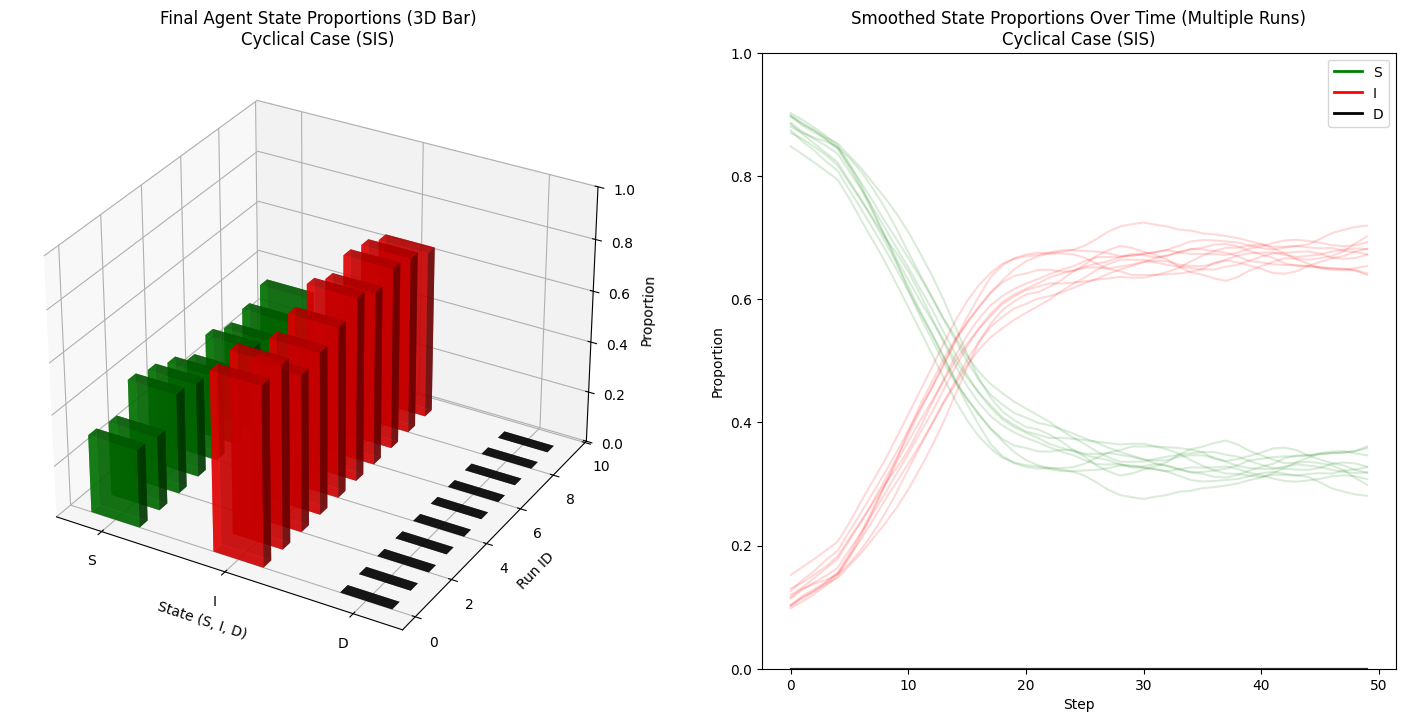

array([4.9000000e+01, 0.0000000e+00, 7.0580000e-01, 2.7694700e+01,
       4.8608000e+00, 1.1492000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 4.9410000e+02, 9.1310000e+02, 8.9200000e+01,
       8.2390000e+02, 1.8477633e+00])

In [13]:

params_sis = dict(
    grid_size=25, num_agents=500, agent_class=FullAgent, init_infected_proportion=0.1,
    proportion_vulnerable=0.1, vul_penalty=0.1,
    infection_prob=0.25, recovery_time=30, death_prob=0,
    vax_vulnerable=False, vax_all=False, vax_effect=0.7,
    viral_age_effect=0, immune_adaptation_effect=0
)
run_multiple_simulations(N_RUNS, params_sis, steps=SIM_STEPS, title_suffix="Cyclical Case (SIS)")


# Death (SID)
- Death prob 0.01
- Otherwise same as SIS

Running 10 simulations for Death (SID)...


/var/folders/cn/qh7p_5sj6qg3561bhy49j8cm0000gp/T/ipykernel_6740/178230261.py:113: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


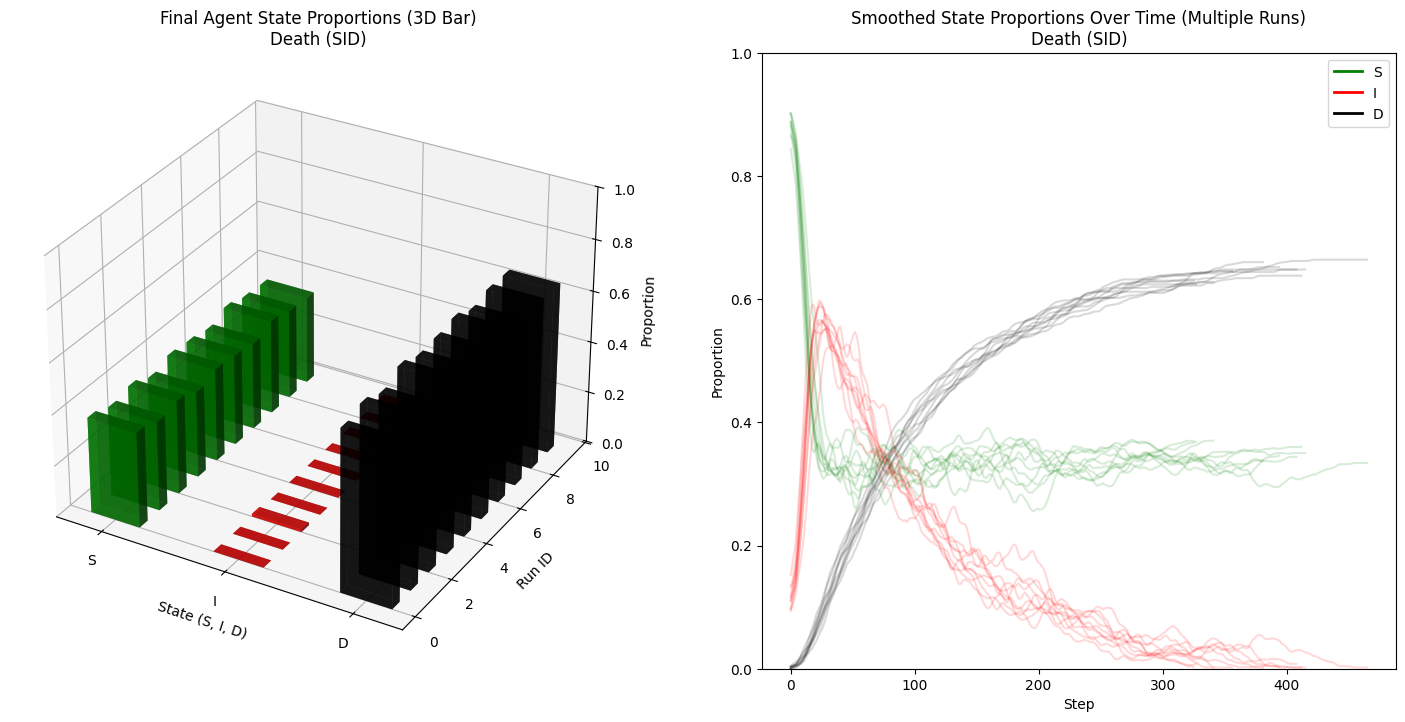

array([3.82400000e+02, 6.44000000e-01, 5.82800000e-01, 6.45867000e+01,
       1.54308000e+01, 3.11700000e+00, 6.39682144e-01, 6.82856935e-01,
       0.00000000e+00, 4.99700000e+02, 1.88140000e+03, 1.82000000e+02,
       1.69940000e+03, 3.76506613e+00])

In [14]:

params_sid = dict(
    grid_size=25, num_agents=500, agent_class=FullAgent, init_infected_proportion=0.1,
    proportion_vulnerable=0.1, vul_penalty=0.1,
    infection_prob=0.25, recovery_time=30, death_prob=0.01,
    vax_vulnerable=False, vax_all=False, vax_effect=0.7,
    viral_age_effect=0, immune_adaptation_effect=0
)
run_multiple_simulations(N_RUNS, params_sid, steps=SIM_STEPS, title_suffix="Death (SID)")


# Viral Aging and Immunity, but no Death (SIIM)

Running 10 simulations for Viral Aging & Immunity (No Death)...


/var/folders/cn/qh7p_5sj6qg3561bhy49j8cm0000gp/T/ipykernel_6740/178230261.py:113: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


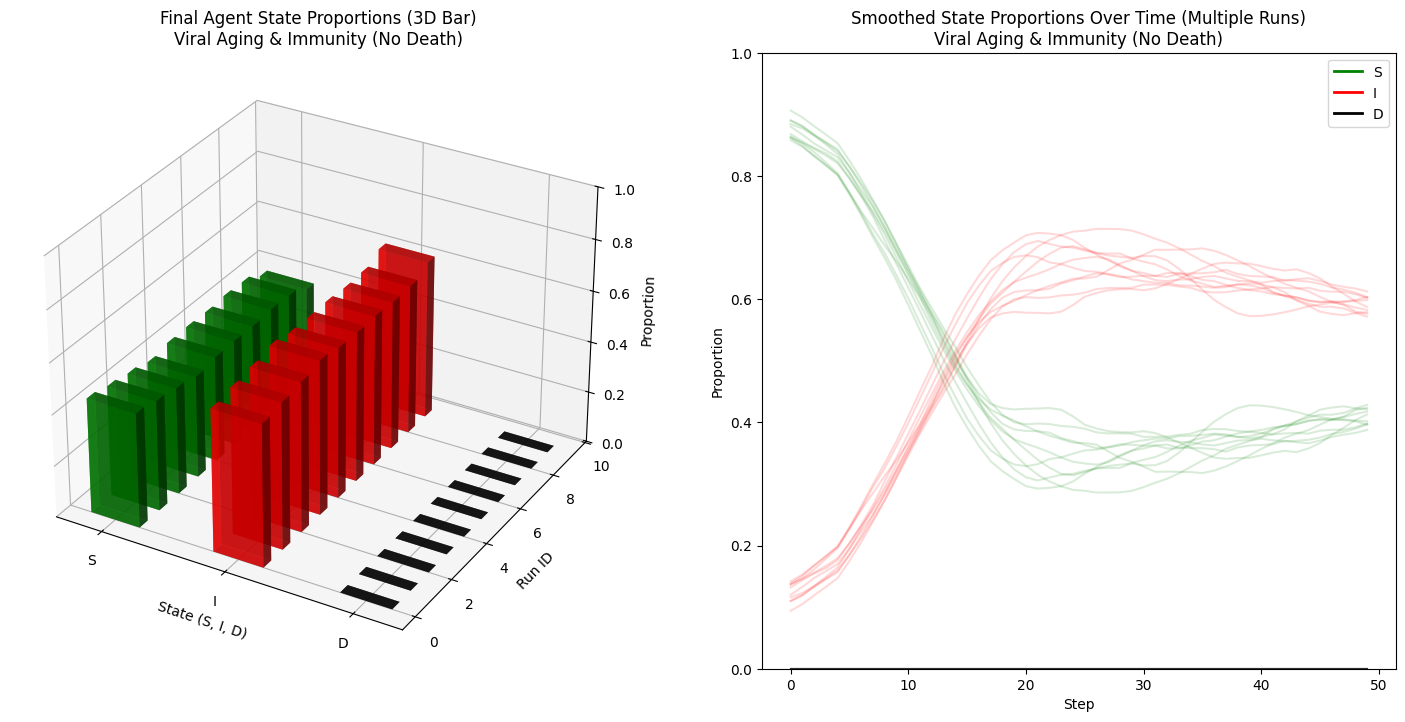

array([4.90000000e+01, 0.00000000e+00, 6.84800000e-01, 2.68030000e+01,
       4.61720000e+00, 1.20120000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 4.91500000e+02, 8.93600000e+02, 8.54000000e+01,
       8.08200000e+02, 1.81805961e+00])

In [15]:

params_siim = dict(
    grid_size=25, num_agents=500, agent_class=FullAgent, init_infected_proportion=0.1,
    proportion_vulnerable=0.1, vul_penalty=0.1,
    infection_prob=0.25, recovery_time=30, death_prob=0,
    vax_vulnerable=False, vax_all=False, vax_effect=0.7,
    viral_age_effect=0.1, immune_adaptation_effect=0.1
)
run_multiple_simulations(N_RUNS, params_siim, steps=SIM_STEPS, title_suffix="Viral Aging & Immunity (No Death)")


# All Mechanics (Death + Aging + Immunity)

Running 10 simulations for All Mechanics...


/var/folders/cn/qh7p_5sj6qg3561bhy49j8cm0000gp/T/ipykernel_6740/178230261.py:113: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


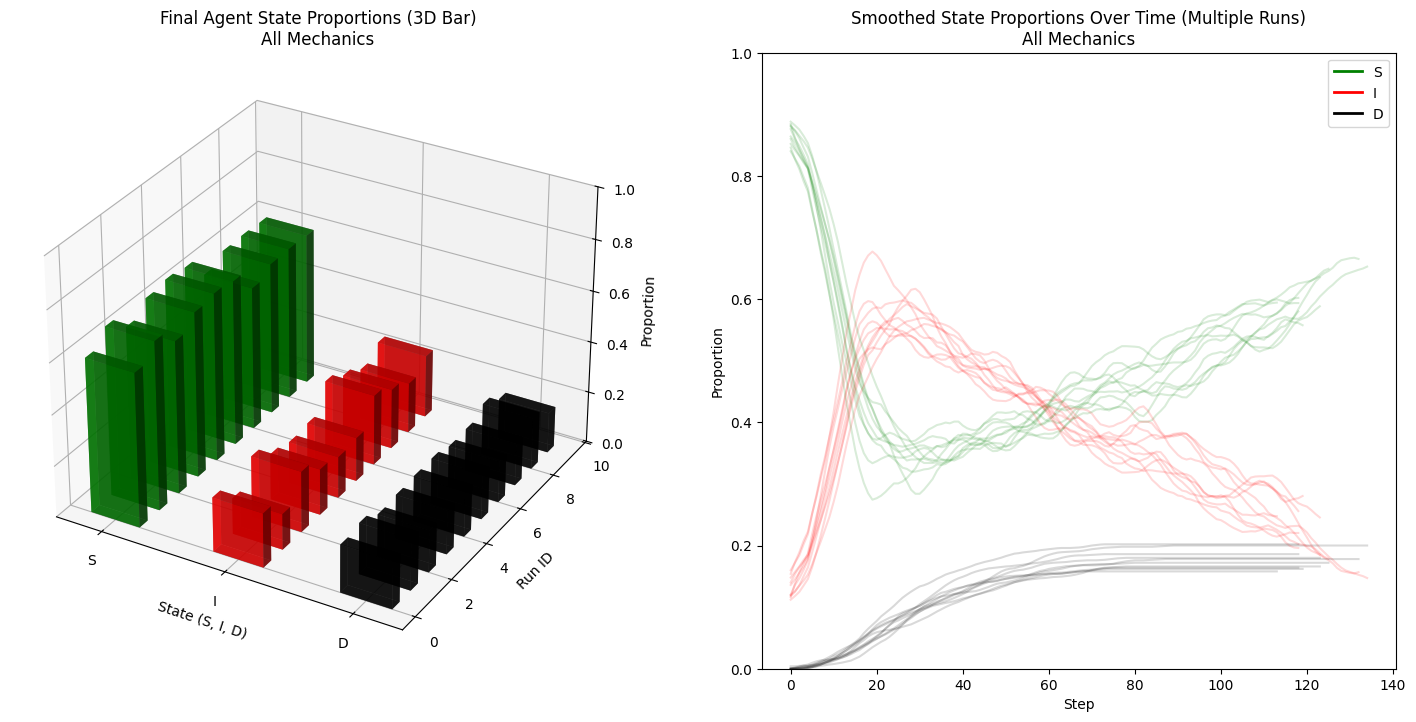

array([1.22300000e+02, 1.76800000e-01, 6.00000000e-01, 4.72100000e+01,
       1.04228000e+01, 2.68840000e+00, 1.72879020e-01, 2.06756753e-01,
       0.00000000e+00, 4.99600000e+02, 1.53560000e+03, 1.66300000e+02,
       1.36930000e+03, 3.07362004e+00])

In [16]:

params_all = dict(
    grid_size=25, num_agents=500, agent_class=FullAgent, init_infected_proportion=0.1,
    proportion_vulnerable=0.1, vul_penalty=0.1,
    infection_prob=0.25, recovery_time=30, death_prob=0.01,
    vax_vulnerable=False, vax_all=False, vax_effect=0.7,
    viral_age_effect=0.1, immune_adaptation_effect=0.1
)
run_multiple_simulations(N_RUNS, params_all, steps=SIM_STEPS, title_suffix="All Mechanics")


# Vax Vulnerable
- vul_penalty=2
- vax_vulnerable=True

Running 10 simulations for Vaccinate Vulnerable...


/var/folders/cn/qh7p_5sj6qg3561bhy49j8cm0000gp/T/ipykernel_6740/178230261.py:113: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


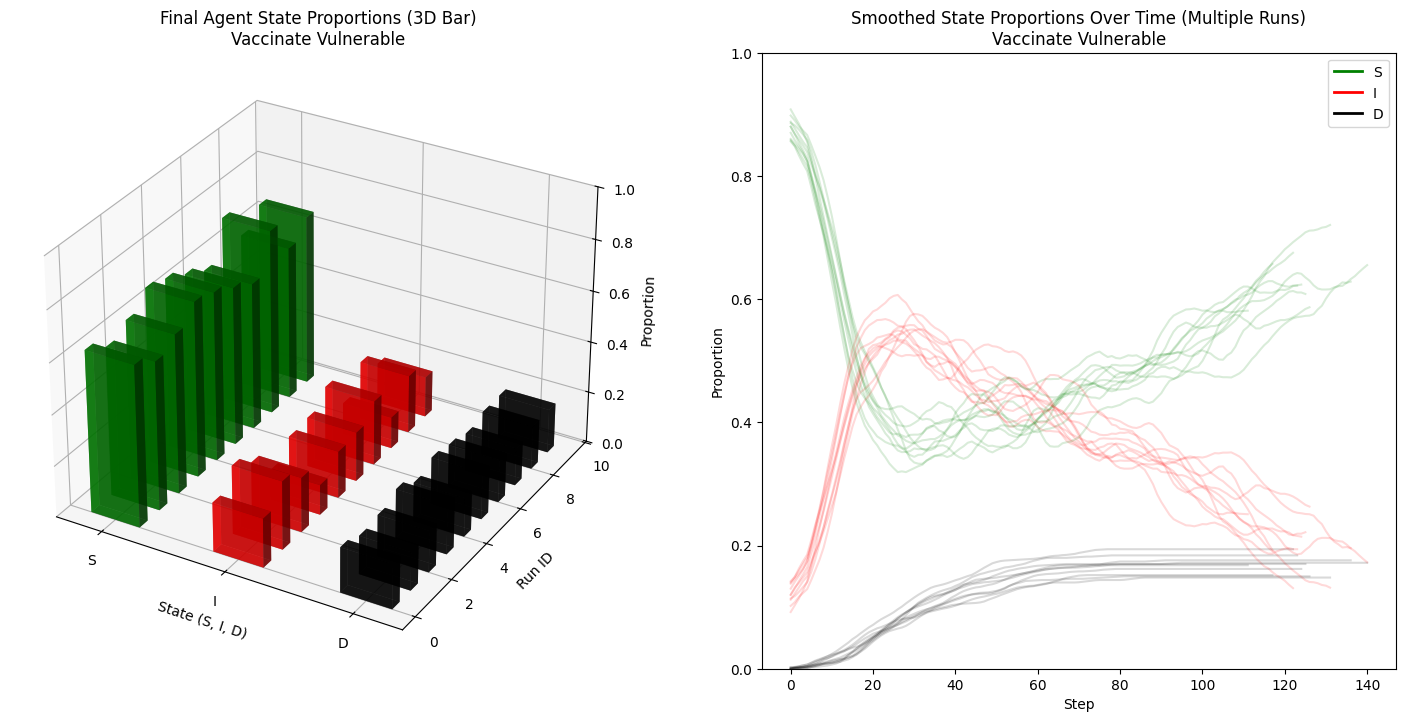

array([1.25500000e+02, 1.67600000e-01, 5.62800000e-01, 4.67171000e+01,
       1.06000000e+01, 2.73000000e+00, 1.72685391e-01, 1.20556026e-01,
       0.00000000e+00, 4.99200000e+02, 1.54560000e+03, 1.52900000e+02,
       1.39270000e+03, 3.09599920e+00])

In [17]:

params_vax_vul = dict(
    grid_size=25, num_agents=500, agent_class=FullAgent, init_infected_proportion=0.1,
    proportion_vulnerable=0.1, vul_penalty=2,
    infection_prob=0.25, recovery_time=30, death_prob=0.01,
    vax_vulnerable=True, vax_all=False, vax_effect=0.7,
    viral_age_effect=0.1, immune_adaptation_effect=0.1
)
run_multiple_simulations(N_RUNS, params_vax_vul, steps=SIM_STEPS, title_suffix="Vaccinate Vulnerable")


# Vax All
- vul_penalty=2
- vax_all=True
- Reduced aging/immunity (0.05)

Running 10 simulations for Vaccinate All...


/var/folders/cn/qh7p_5sj6qg3561bhy49j8cm0000gp/T/ipykernel_6740/178230261.py:113: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


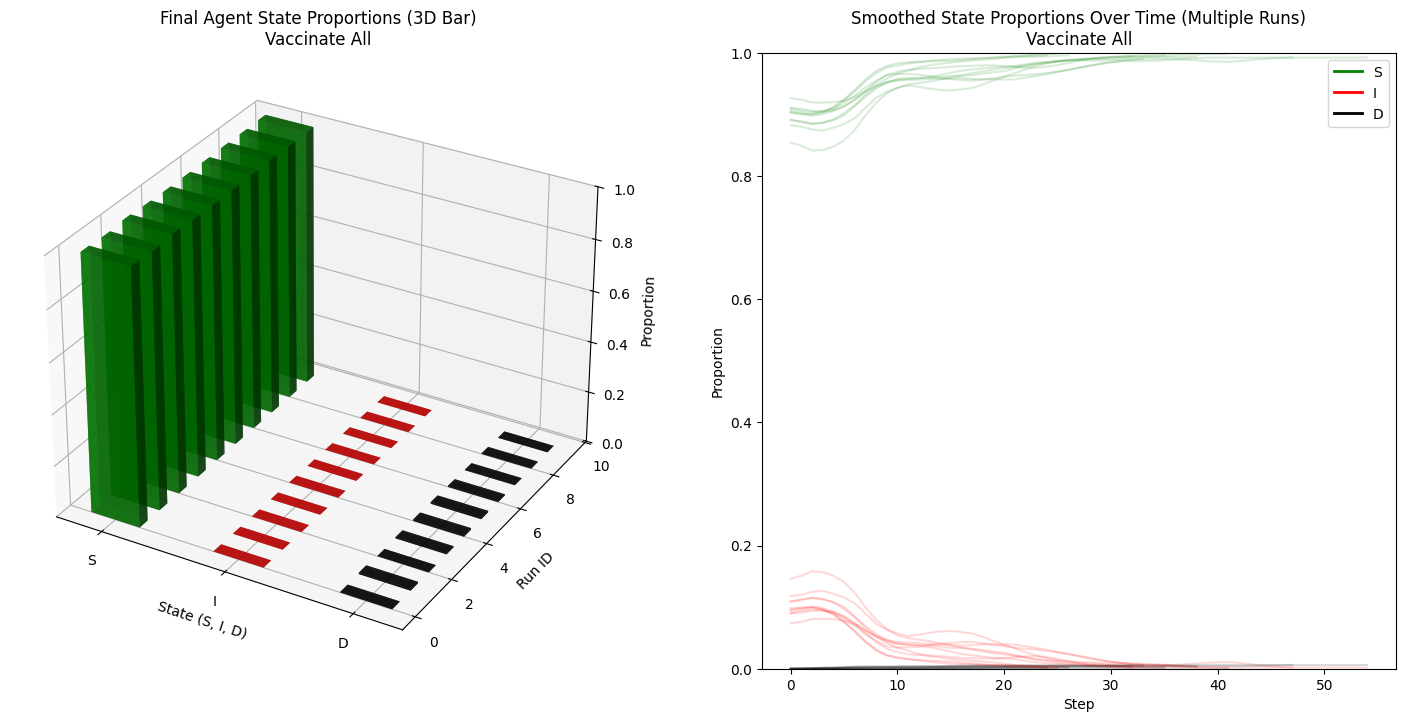

array([3.55000000e+01, 3.20000000e-03, 1.14800000e-01, 1.06800000e+00,
       1.51000000e-01, 1.65200000e-01, 1.09813327e-03, 2.18925821e-02,
       0.00000000e+00, 8.13000000e+01, 8.42000000e+01, 1.24000000e+01,
       7.18000000e+01, 1.03179886e+00])

In [18]:

params_vax_all = dict(
    grid_size=25, num_agents=500, agent_class=FullAgent, init_infected_proportion=0.1,
    proportion_vulnerable=0.1, vul_penalty=2,
    infection_prob=0.25, recovery_time=30, death_prob=0.01,
    vax_vulnerable=True, vax_all=True, vax_effect=0.7,
    viral_age_effect=0.05, immune_adaptation_effect=0.05
)
run_multiple_simulations(N_RUNS, params_vax_all, steps=SIM_STEPS, title_suffix="Vaccinate All")
